In [1]:
# --- IMPORT LIBRARIES ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Perceptron, Ridge, Lasso
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler  # Corrected import
from sklearn.metrics import RocCurveDisplay

In [2]:
# --- LOAD AND PREPARE DATASET (Breast Cancer Wisconsin) ---
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target,name='target')

# Feature selection for demonstration purposes
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
X = X[selected_features]

# Add noise to create more realistic regression target
np.random.seed(42)
#y_regression = X['mean area'] * 10 + np.random.normal(0, 20, len(X))
y_regression = pd.Series(X['mean area'] * 10 + np.random.normal(0, 20, len(X)), name='reg_target')

print("Dataset shape:", X.shape)
print("Features:", selected_features)
print("\nFirst 5 samples:")
display(X.head())
display(y.head())

# --- TRAIN-TEST SPLIT ---
X_train, X_test, y_train, y_test, y_train_reg, y_test_reg = train_test_split(
    X, y, y_regression, test_size=0.2, random_state=42
)

# Standardize features for regularized models and perceptron
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Dataset shape: (569, 4)
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

First 5 samples:


,mean radius,mean texture,mean perimeter,mean area
0,17.99,10.38,122.80,1001.0
1,20.57,17.77,132.90,1326.0
2,19.69,21.25,130.00,1203.0
3,11.42,20.38,77.58,386.1
4,20.29,14.34,135.10,1297.0


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


1. ORDINARY LEAST SQUARES (OLS) REGRESSION

OLS Coefficients:
mean radius: -2.2760
mean texture: -0.2516
mean perimeter: 0.0209
mean area: 10.0220
Intercept: 20.4973

Test MSE: 346.11


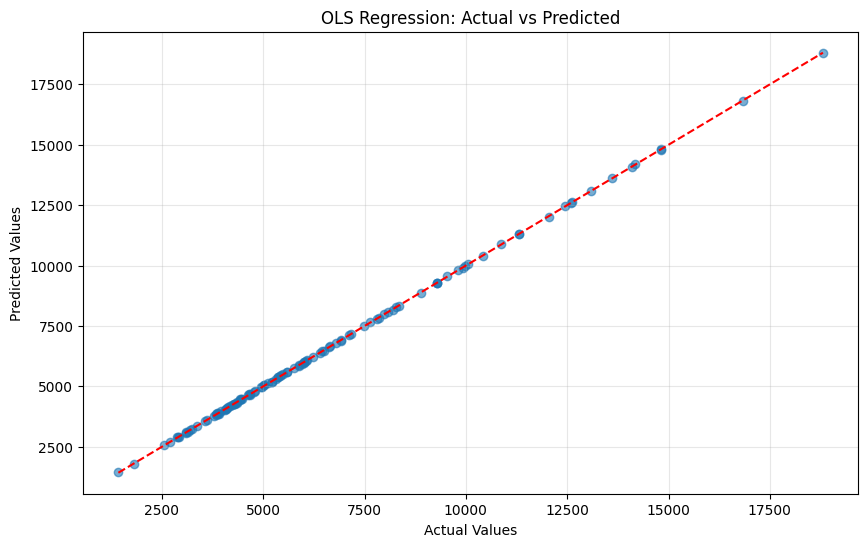

In [3]:
# ====================================================================
# 1. ORDINARY LEAST SQUARES (OLS) REGRESSION
# ====================================================================
print("\n" + "="*50)
print("1. ORDINARY LEAST SQUARES (OLS) REGRESSION")
print("="*50)

ols = LinearRegression()
ols.fit(X_train, y_train_reg)
ols_pred = ols.predict(X_test)
ols_mse = mean_squared_error(y_test_reg, ols_pred)

print("\nOLS Coefficients:")
for feature, coef in zip(selected_features, ols.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {ols.intercept_:.4f}")
print(f"\nTest MSE: {ols_mse:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, ols_pred, alpha=0.6)
plt.plot([min(y_test_reg), max(y_test_reg)], [min(y_test_reg), max(y_test_reg)], 'r--')
plt.title("OLS Regression: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(alpha=0.3)
plt.show()



2. WEIGHTED LEAST SQUARES (WLS) REGRESSION

WLS Coefficients:
mean radius: 0.3227
mean texture: -0.2450
mean perimeter: -0.1940
mean area: 10.0102
Intercept: 11.1204

Test MSE: 347.09


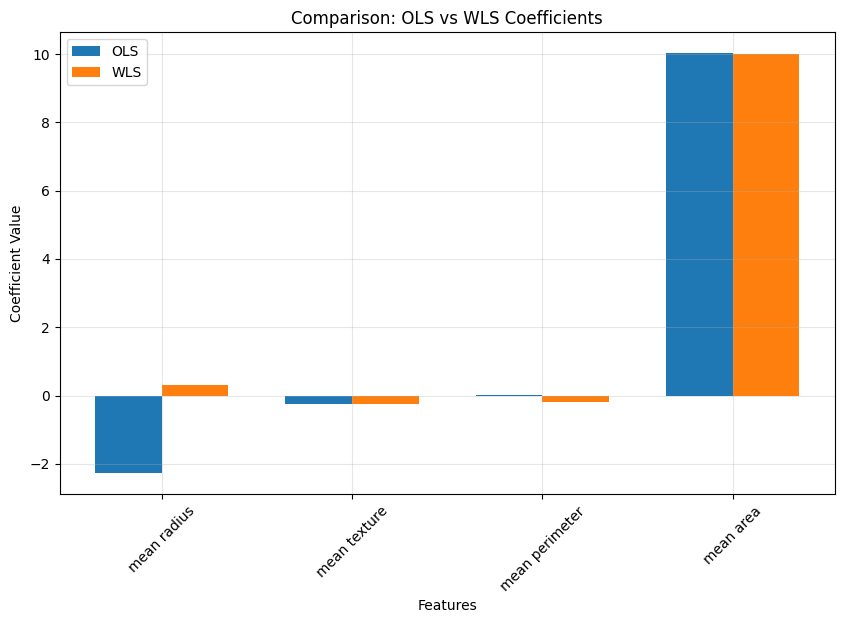

In [4]:
# ====================================================================
# 2. WEIGHTED LEAST SQUARES (WLS) REGRESSION
# ====================================================================
print("\n" + "="*50)
print("2. WEIGHTED LEAST SQUARES (WLS) REGRESSION")
print("="*50)

weights = 1 / (X_train['mean radius'] ** 2)  # Larger observations get lower weights
wls = LinearRegression()
wls.fit(X_train, y_train_reg, sample_weight=weights)
wls_pred = wls.predict(X_test)
wls_mse = mean_squared_error(y_test_reg, wls_pred)

print("\nWLS Coefficients:")
for feature, coef in zip(selected_features, wls.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {wls.intercept_:.4f}")
print(f"\nTest MSE: {wls_mse:.2f}")

plt.figure(figsize=(10, 6))
index = np.arange(len(selected_features))
bar_width = 0.35
plt.bar(index, ols.coef_, bar_width, label='OLS')
plt.bar(index + bar_width, wls.coef_, bar_width, label='WLS')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Comparison: OLS vs WLS Coefficients')
plt.xticks(index + bar_width/2, selected_features, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


3. LOGISTIC REGRESSION (Classification)

Logistic Regression Coefficients:
mean radius: 30.2316
mean texture: -1.0674
mean perimeter: -26.1851
mean area: -9.6893
Intercept: -0.2147

Accuracy: 0.9386
ROC AUC: 0.9912


/home/pyjast1123/MachineLearning/MTH129/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


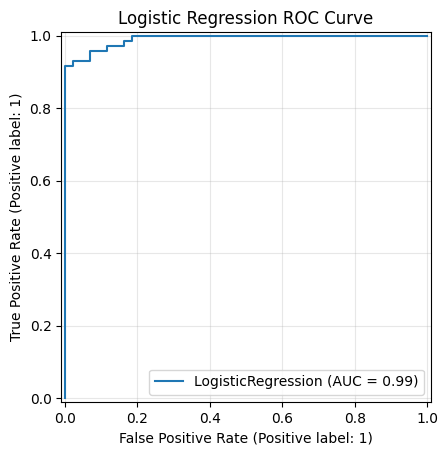

In [5]:
# ====================================================================
# 3. LOGISTIC REGRESSION (Classification)
# ====================================================================
print("\n" + "="*50)
print("3. LOGISTIC REGRESSION (Classification)")
print("="*50)

log_reg = LogisticRegression(penalty=None, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
accuracy = accuracy_score(y_test, log_reg_pred)
roc_auc = roc_auc_score(y_test, log_reg_prob)

print("\nLogistic Regression Coefficients:")
for feature, coef in zip(selected_features, log_reg.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {log_reg.intercept_[0]:.4f}")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

RocCurveDisplay.from_estimator(log_reg, X_test_scaled, y_test)
plt.title('Logistic Regression ROC Curve')
plt.grid(alpha=0.3)
plt.show()


4. PERCEPTRON (Linear Classifier)

Perceptron Coefficients:
mean radius: 0.7220
mean texture: -0.0150
mean perimeter: -1.1757
mean area: -0.1103
Intercept: 0.0000

Accuracy: 0.9123


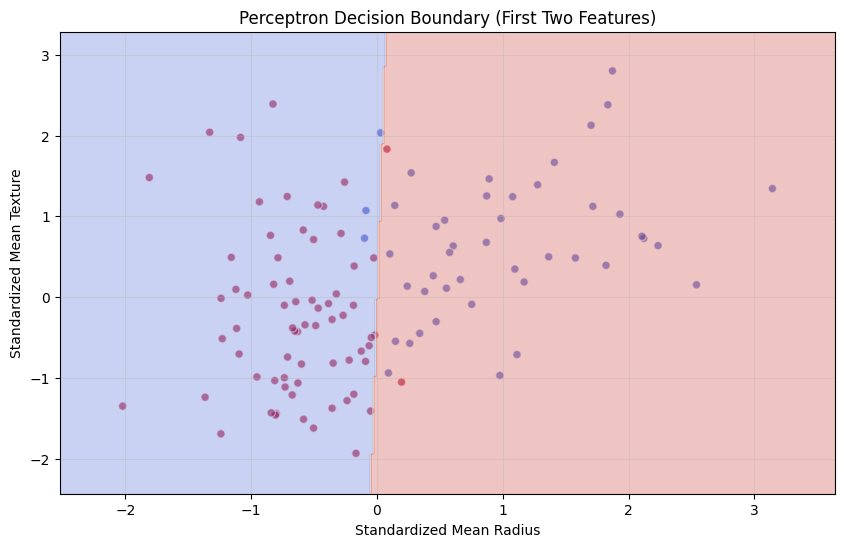

In [6]:
# ====================================================================
# 4. PERCEPTRON (Linear Classifier)
# ====================================================================
print("\n" + "="*50)
print("4. PERCEPTRON (Linear Classifier)")
print("="*50)

perceptron = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
perceptron.fit(X_train_scaled, y_train)
perceptron_pred = perceptron.predict(X_test_scaled)
accuracy = accuracy_score(y_test, perceptron_pred)

print("\nPerceptron Coefficients:")
for feature, coef in zip(selected_features, perceptron.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {perceptron.intercept_[0]:.4f}")
print(f"\nAccuracy: {accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=perceptron_pred, 
            cmap='coolwarm', alpha=0.6, edgecolors='w')

x_min, x_max = X_test_scaled[:, 0].min() - 0.5, X_test_scaled[:, 0].max() + 0.5
y_min, y_max = X_test_scaled[:, 1].min() - 0.5, X_test_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel(),
                            np.zeros_like(xx.ravel()),
                            np.zeros_like(xx.ravel())])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.title("Perceptron Decision Boundary (First Two Features)")
plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.grid(alpha=0.3)
plt.show()


5. PENALIZED OLS (Ridge & Lasso Regression)

Ridge Coefficients:
mean radius: 143.7027
mean texture: -2.5298
mean perimeter: 111.8191
mean area: 3287.0783
Intercept: 6543.6223
Test MSE: 1612.19

Lasso Coefficients:
mean radius: -40.5566
mean texture: -1.2037
mean perimeter: 28.8859
mean area: 3557.3672
Intercept: 6543.6223
Test MSE: 350.84


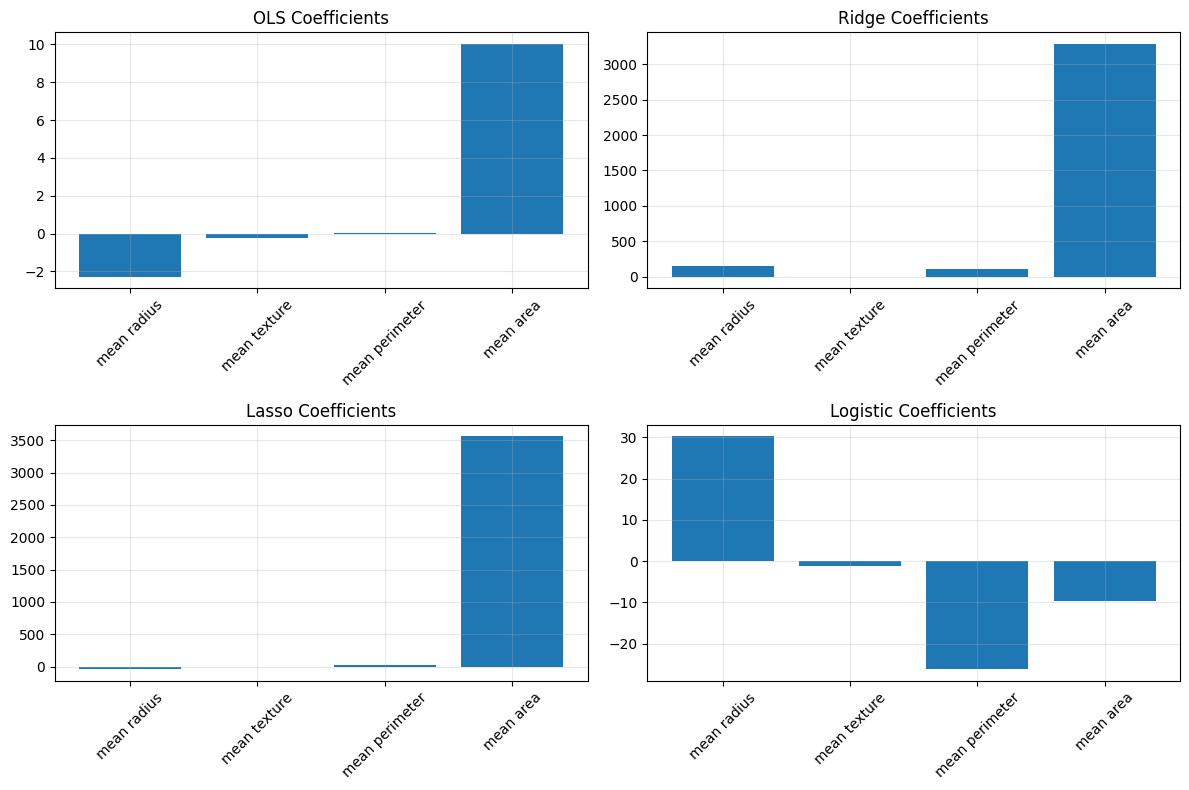

In [7]:
# ====================================================================
# 5. PENALIZED OLS (Ridge & Lasso Regression)
# ====================================================================
print("\n" + "="*50)
print("5. PENALIZED OLS (Ridge & Lasso Regression)")
print("="*50)

ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1, max_iter=10000)
ridge.fit(X_train_scaled, y_train_reg)
lasso.fit(X_train_scaled, y_train_reg)

ridge_pred = ridge.predict(X_test_scaled)
lasso_pred = lasso.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test_reg, ridge_pred)
lasso_mse = mean_squared_error(y_test_reg, lasso_pred)

print("\nRidge Coefficients:")
for feature, coef in zip(selected_features, ridge.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {ridge.intercept_:.4f}")
print(f"Test MSE: {ridge_mse:.2f}")

print("\nLasso Coefficients:")
for feature, coef in zip(selected_features, lasso.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {lasso.intercept_:.4f}")
print(f"Test MSE: {lasso_mse:.2f}")

models = [('OLS', ols.coef_), 
          ('Ridge', ridge.coef_), 
          ('Lasso', lasso.coef_),
          ('Logistic', log_reg.coef_[0])]

plt.figure(figsize=(12, 8))
for i, model in enumerate(models):
    plt.subplot(2, 2, i+1)
    plt.bar(selected_features, model[1])
    plt.title(f'{model[0]} Coefficients')
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


6. PENALIZED LOGISTIC REGRESSION (L1 & L2 Regularization)

L1 Regularized (Lasso) Logistic Coefficients:
mean radius: 0.0000
mean texture: -0.6255
mean perimeter: -2.6445
mean area: 0.0000
Intercept: 0.6749
Accuracy: 0.9123

L2 Regularized (Ridge) Logistic Coefficients:
mean radius: -0.8186
mean texture: -0.6964
mean perimeter: -1.0921
mean area: -0.7705
Intercept: 0.6267
Accuracy: 0.9035


/home/pyjast1123/MachineLearning/MTH129/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pyjast1123/MachineLearning/MTH129/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/pyjast1123/MachineLearning/MTH129/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe

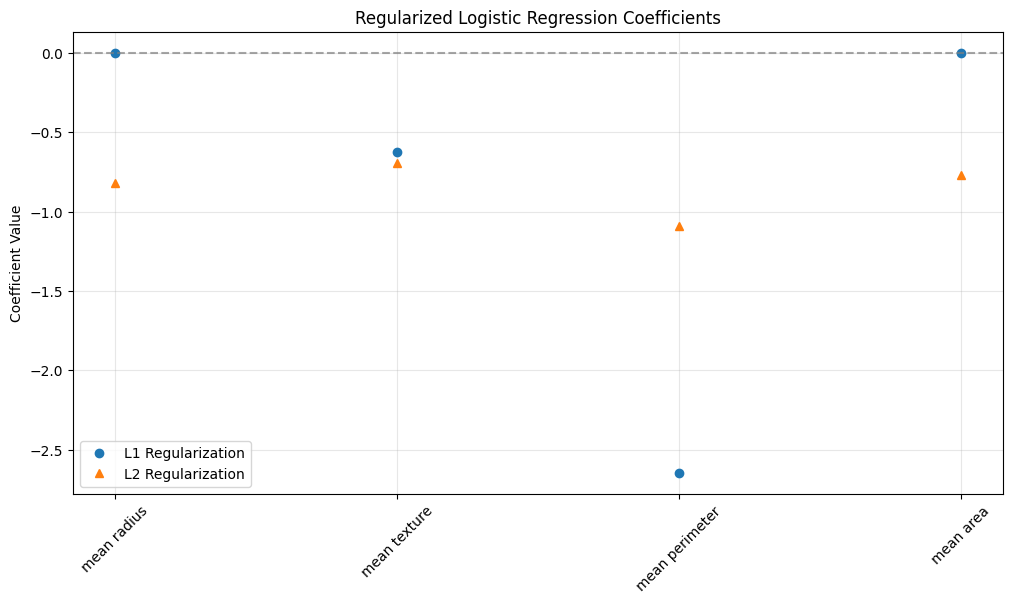

In [8]:
# ====================================================================
# 6. PENALIZED LOGISTIC REGRESSION (L1 & L2 Regularization)
# ====================================================================
print("\n" + "="*50)
print("6. PENALIZED LOGISTIC REGRESSION (L1 & L2 Regularization)")
print("="*50)

log_reg_l1 = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, C=0.1)
log_reg_l2 = LogisticRegression(penalty='l2', max_iter=1000, C=0.1)
log_reg_l1.fit(X_train_scaled, y_train)
log_reg_l2.fit(X_train_scaled, y_train)

log_reg_l1_pred = log_reg_l1.predict(X_test_scaled)
log_reg_l2_pred = log_reg_l2.predict(X_test_scaled)
accuracy_l1 = accuracy_score(y_test, log_reg_l1_pred)
accuracy_l2 = accuracy_score(y_test, log_reg_l2_pred)

print("\nL1 Regularized (Lasso) Logistic Coefficients:")
for feature, coef in zip(selected_features, log_reg_l1.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {log_reg_l1.intercept_[0]:.4f}")
print(f"Accuracy: {accuracy_l1:.4f}")

print("\nL2 Regularized (Ridge) Logistic Coefficients:")
for feature, coef in zip(selected_features, log_reg_l2.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {log_reg_l2.intercept_[0]:.4f}")
print(f"Accuracy: {accuracy_l2:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(log_reg_l1.coef_[0], 'o', label='L1 Regularization')
plt.plot(log_reg_l2.coef_[0], '^', label='L2 Regularization')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
plt.xticks(range(len(selected_features)), selected_features, rotation=45)
plt.title("Regularized Logistic Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()